<a href="https://colab.research.google.com/github/zxcvnm05/ecommerce_customer_behavior_analysis/blob/main/EDA_group_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 3 EDA Pipeline:**
1. Load cleaned dataset
2. Conduct descriptive statistics
3. Create frequency and percentage tables
4. Analyze RQ1: demographics and order value
5. Analyze RQ2: payment method, purchasing behavior, and return likelihood
6. Analyze RQ3: product categories and return frequency
7. Analyze RQ4: delivery duration and customer ratings
8. Conduct trend analysis
9. Conduct correlation analysis
10. Summarize key insights and managerial recommendations

**Import Libraries**

Import the required libraries for data analysis, visualization, and basic statistical testing.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

Load Cleaned Dataset
Load the cleaned dataset from Part 2 and convert order_date into datetime format for trend analysis.

In [ ]:
df = pd.read_csv("ecommerce_customer_behavior_cleaned.csv")
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

Dataset shape: (4971, 19)
Columns: ['order_id', 'customer_age', 'customer_gender', 'product_category', 'payment_method', 'order_value_usd', 'delivery_time_days', 'customer_rating', 'returned', 'order_date', 'returned_flag', 'age_group', 'order_value_segment', 'delivery_speed', 'order_year', 'order_month', 'order_quarter', 'order_month_year', 'is_high_value_order']


,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date,returned_flag,age_group,order_value_segment,delivery_speed,order_year,order_month,order_quarter,order_month_year,is_high_value_order
0,1,37,Other,Home & Living,Credit Card,1366.60,10,2.3,No,2022-01-01,0,36-45,High value,Slow delivery,2022,1,1,2022-01,1
1,2,41,Female,Fashion,Credit Card,1175.89,6,1.8,Yes,2022-01-02,1,36-45,High value,Standard delivery,2022,1,1,2022-01,1
2,3,30,Other,Sports,Credit Card,1283.97,7,3.2,No,2022-01-03,0,26-35,High value,Standard delivery,2022,1,1,2022-01,1
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,No,2022-01-04,0,56-69,High value,Slow delivery,2022,1,1,2022-01,1
4,5,59,Other,Fashion,Credit Card,1411.06,7,3.2,No,2022-01-05,0,56-69,High value,Standard delivery,2022,1,1,2022-01,1


# **A. Descriptive Statistics and Frequency Tables**





## **I. Descriptive Statistics**
Generate descriptive statistics for key numerical variables and summarize the overall business performance of the dataset

Numerical Variables


,customer_age,order_value_usd,delivery_time_days,customer_rating
count,4971.00,4971.00,4971.00,4971.00
mean,43.27,750.31,7.46,3.02
std,15.00,432.63,4.01,1.14
min,18.00,5.57,1.00,1.00
25%,30.00,366.88,4.00,2.10
50%,43.00,757.90,7.00,3.00
75%,56.00,1120.86,11.00,4.00
max,69.00,2251.81,14.00,5.00



Overall Business Summary


,Metric,Value
0,Total orders,4971.00
1,Total order value (USD),3729774.77
2,Average order value (USD),750.31
3,Median order value (USD),757.90
4,Overall return rate (%),50.49
5,Average customer rating,3.02
6,Average delivery time (days),7.46


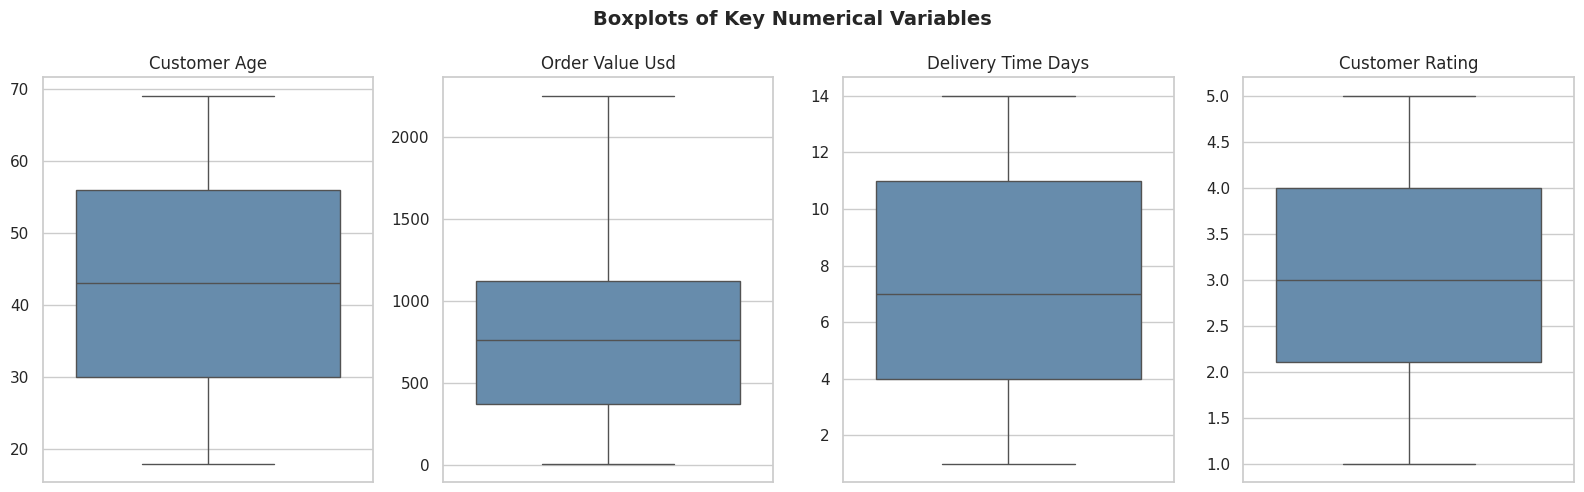

In [ ]:
print("Numerical Variables")

numerical_cols = [
    "customer_age",
    "order_value_usd",
    "delivery_time_days",
    "customer_rating"
]

display(df[numerical_cols].describe().round(2))


print("\nOverall Business Summary")

summary = pd.DataFrame({
    "Metric": [
        "Total orders",
        "Total order value (USD)",
        "Average order value (USD)",
        "Median order value (USD)",
        "Overall return rate (%)",
        "Average customer rating",
        "Average delivery time (days)"
    ],
    "Value": [
        len(df),
        round(df["order_value_usd"].sum(), 2),
        round(df["order_value_usd"].mean(), 2),
        round(df["order_value_usd"].median(), 2),
        round(df["returned_flag"].mean() * 100, 2),
        round(df["customer_rating"].mean(), 2),
        round(df["delivery_time_days"].mean(), 2)
    ]
})

display(summary)


# Boxplots for key numerical variables
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, numerical_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=ax,
        color="#5b8db8"
    )

    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle(
    "Boxplots of Key Numerical Variables",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

This section produces:
Descriptive statistics for numerical variables\
Overall business summary\
Total orders\
Total order value\
Average order value\
Median order value\
Overall return rate\
Average customer rating\
Average delivery time\
This helps establish a general understanding of customer purchasing behavior, satisfaction level, delivery performance, and return behavior before answering the research questions

## **II. Frequency Tables**
Create frequency tables for key categorical variables.

In [ ]:
for col, label in [
    ("product_category", "Product Category"),
    ("payment_method", "Payment Method"),
    ("customer_gender", "Customer Gender"),
    ("age_group", "Age Group"),
    ("delivery_speed", "Delivery Speed"),
    ("returned", "Returned"),
    ("order_value_segment", "Order Value Segment")
]:
    freq_table = pd.DataFrame({
        "Frequency": df[col].value_counts(),
        "Percentage (%)": round(df[col].value_counts(normalize=True) * 100, 2)
    })

    print(f"\n{label}")
    display(freq_table)


Product Category


,Frequency,Percentage (%)
product_category,,
Fashion,845,17.00
Beauty,845,17.00
Sports,843,16.96
Groceries,829,16.68
Electronics,811,16.31
Home & Living,798,16.05



Payment Method


,Frequency,Percentage (%)
payment_method,,
Credit Card,1070,21.52
UPI,1008,20.28
Wallet,989,19.90
Debit Card,972,19.55
Cash on Delivery,932,18.75



Customer Gender


...

,Frequency,Percentage (%)
delivery_speed,,
Slow delivery,2423,48.74
Standard delivery,1495,30.07
Fast delivery,1053,21.18



Returned


,Frequency,Percentage (%)
returned,,
Yes,2510,50.49
No,2461,49.51



Order Value Segment


,Frequency,Percentage (%)
order_value_segment,,
High value,1657,33.33
Medium value,1657,33.33
Low value,1657,33.33


Frequency tables are created for:\
Product category\
Payment method\
Customer gender\
Age group\
Delivery speed\
Return status\
Order value segment\
These frequency tables help identify whether the dataset is balanced across customer groups, product categories, and payment methods. They also provide a foundation for group comparison in later sections.

# **B. RQ1 - Customer Demographics and Order Value**
How do customer demographics, age and gender, influence total order values?




## **I. RQ1 Summary Tables**
Create summary tables to compare order value by:
Age group,
Gender,
Age group × Gender

In [ ]:
age_order = ["18-25", "26-35", "36-45", "46-55", "56-69"]

aov_by_age = df.groupby("age_group", observed=False).agg(
    order_count=("order_id", "count"),
    avg_order_value=("order_value_usd", "mean"),
    median_order_value=("order_value_usd", "median"),
    total_order_value=("order_value_usd", "sum")
).round(2)

print("Order value by age group:")
display(aov_by_age)

aov_by_gender = df.groupby("customer_gender").agg(
    order_count=("order_id", "count"),
    avg_order_value=("order_value_usd", "mean"),
    median_order_value=("order_value_usd", "median"),
    total_order_value=("order_value_usd", "sum")
).round(2).sort_values("avg_order_value", ascending=False)

print("\nOrder value by gender:")
display(aov_by_gender)

aov_age_gender = (
    df.groupby(["age_group", "customer_gender"], observed=False)["order_value_usd"]
    .mean()
    .round(2)
    .unstack()
)

print("\nAverage order value — Age Group × Gender:")
display(aov_age_gender)

Order value by age group:


,order_count,avg_order_value,median_order_value,total_order_value
age_group,,,,
18-25,782,754.97,760.38,590388.34
26-35,964,736.40,721.08,709892.33
36-45,992,749.89,749.34,743886.08
46-55,918,756.92,779.89,694851.60
56-69,1315,753.43,764.89,990756.42



Order value by gender:


,order_count,avg_order_value,median_order_value,total_order_value
customer_gender,,,,
Female,1629,756.51,774.40,1232352.38
Male,1699,748.99,765.85,1272539.86
Other,1643,745.52,734.07,1224882.53



Average order value — Age Group × Gender:


customer_gender,Female,Male,Other
age_group,,,
18-25,728.55,778.83,756.54
26-35,721.84,760.16,728.67
36-45,781.50,738.47,728.88
46-55,739.20,764.13,766.62
56-69,793.11,721.25,749.74


**These tables help answer whether customer demographics are useful for identifying higher-spending customer segments. They also support managerial decisions related to customer segmentation, targeted marketing, and personalized promotions**

## **II. RQ1 Statistical Test**
Use one-way ANOVA to test whether average order value differs significantly across age groups.

In [ ]:
groups = [
    df[df["age_group"] == g]["order_value_usd"].values
    for g in age_order
]

f_stat, p_val = stats.f_oneway(*groups)

print("One-way ANOVA: Age group vs order value")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value = {p_val:.4f}")

if p_val > 0.05:
    print("Interpretation: No statistically significant difference in order value across age groups.")
else:
    print("Interpretation: A statistically significant difference in order value exists across age groups.")

One-way ANOVA: Age group vs order value
F-statistic = 0.3424
p-value = 0.8494
Interpretation: No statistically significant difference in order value across age groups.


The ANOVA test evaluates whether the differences in average order value across age groups are statistically significant

The p-value is greater than 0.05, the result suggests that there is no statistically significant difference in order value across age groups. In that case, demographic segmentation alone may not be strong enough to explain differences in customer spending.

## **III. RQ1 Charts**
Create three visualizations for RQ1:\
1.Average order value by age group\
2.Order value distribution by gender\
3.Average order value by age group and gender

/tmp/ipykernel_1680/2811143896.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


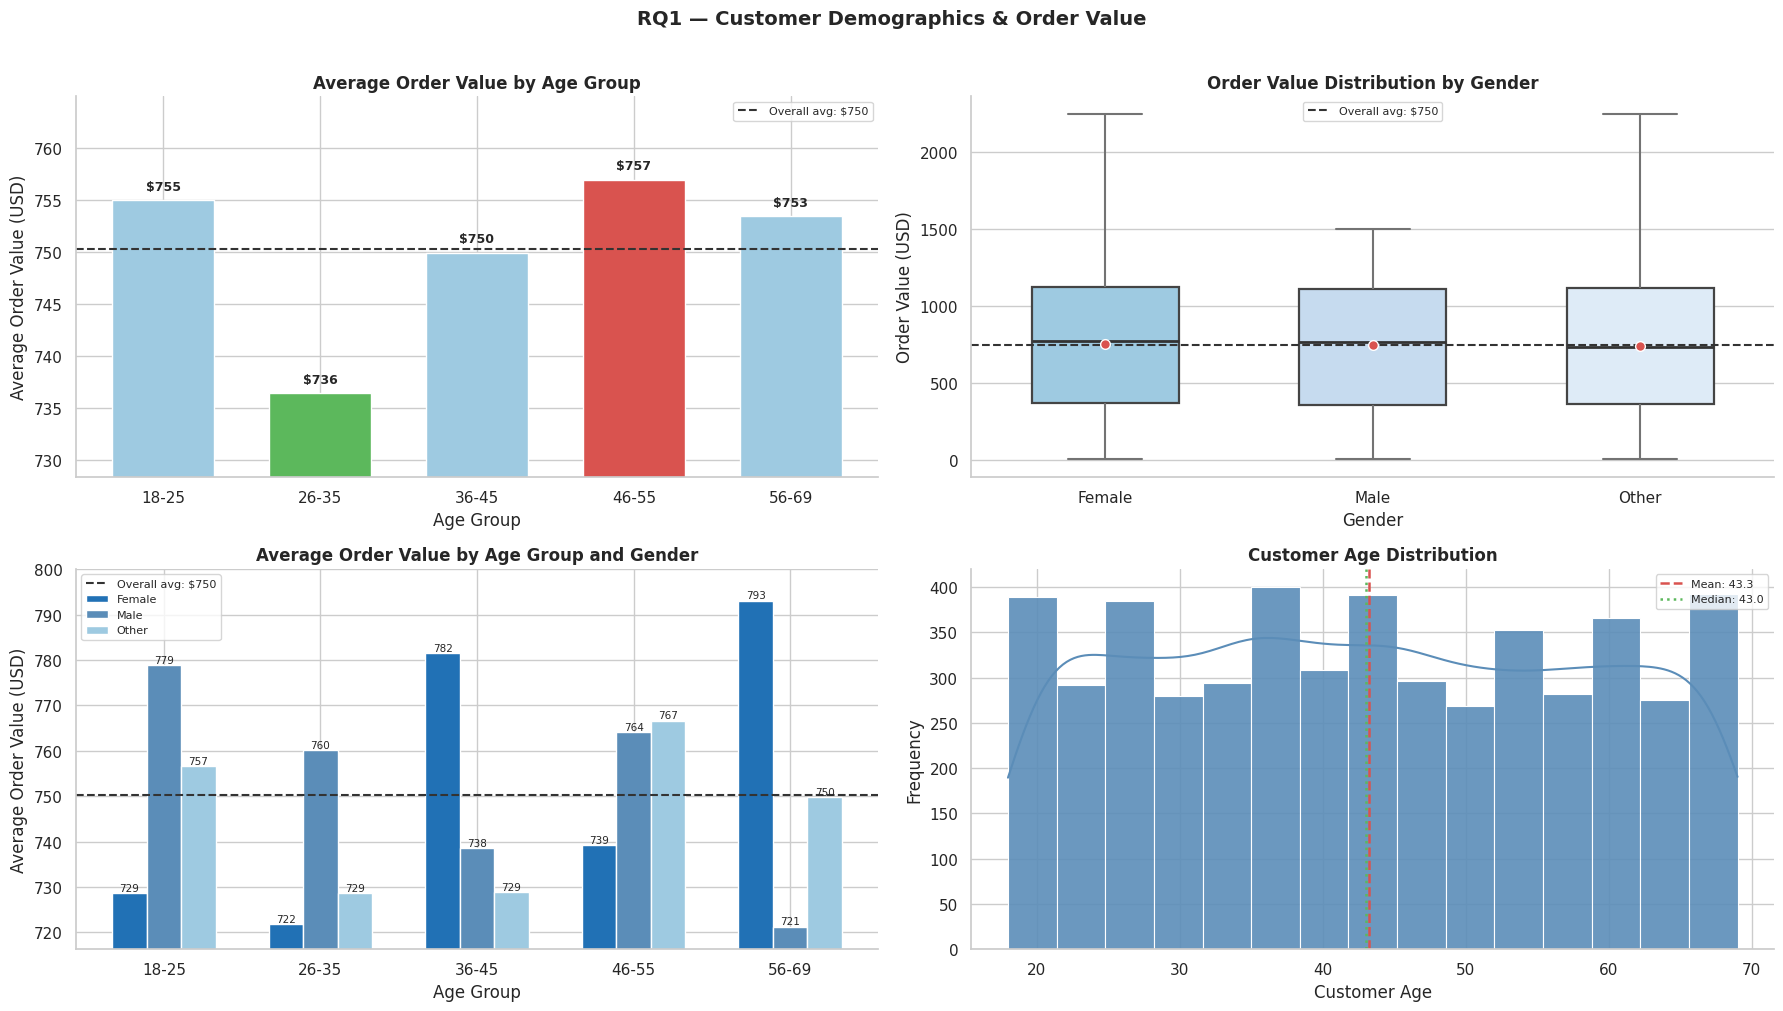

Saved: chart_rq1_demographics.png


In [ ]:
# ĐÃ SỬA
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()
overall_mean = df["order_value_usd"].mean()
gender_order = sorted(df["customer_gender"].dropna().unique())

#color palette
blue_main  = "#5b8db8"
blue_dark  = "#2171b5"
blue_light = "#9ecae1"
green_main = "#5cb85c"
red_main   = "#d9534f"
neutral    = "#333333"

#chart 1: average order value by age group
age_vals = aov_by_age["avg_order_value"].reindex(age_order)

mx = age_vals.max()
mn = age_vals.min()

colors1 = [
    red_main if v == mx else
    green_main if v == mn else
    blue_light
    for v in age_vals
]

bars = axes[0].bar(
    age_vals.index,
    age_vals.values,
    color=colors1,
    edgecolor="white",
    linewidth=1,
    width=0.65
)

# zoom axis to highlight differences
axes[0].set_ylim(
    mn - 8,
    mx + 8
)

axes[0].axhline(
    overall_mean,
    color=neutral,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall avg: ${overall_mean:.0f}"
)

for bar, val in zip(bars, age_vals.values):

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        f"${val:.0f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

axes[0].set_title(
    "Average Order Value by Age Group",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Average Order Value (USD)")
axes[0].legend(fontsize=8)

axes[0].spines[["top", "right"]].set_visible(False)

#chart 2: boxplot order value by gender
sns.boxplot(
    data=df,
    x="customer_gender",
    y="order_value_usd",
    order=gender_order,
    palette=[blue_light, "#c6dbef", "#deebf7"],
    linewidth=1.6,
    width=0.55,
    showmeans=True,
    whis=1.5,          # standard whisker range
    saturation=1,
    meanprops={
        "marker": "o",
        "markerfacecolor": red_main,
        "markeredgecolor": "white",
        "markersize": 7
    },
    flierprops={
        "marker": "o",
        "markerfacecolor": "gray",
        "markeredgecolor": "none",
        "markersize": 2,
        "alpha": 0.18
    },
    medianprops={
        "color": "#333333",
        "linewidth": 2
    },
    whiskerprops={
        "linewidth": 1.5
    },
    capprops={
        "linewidth": 1.5
    },
    boxprops={
        "edgecolor": "#444444"
    },
    ax=axes[1]
)

#overall average line
axes[1].axhline(
    overall_mean,
    color=neutral,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall avg: ${overall_mean:.0f}"
)


axes[1].set_title(
    "Order Value Distribution by Gender",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Order Value (USD)")
axes[1].legend(fontsize=8)

axes[1].spines[["top", "right"]].set_visible(False)

#chart 3: Average Order Value by Age Group and Gender
colors_g = [
    blue_dark,
    blue_main,
    blue_light
]

x = np.arange(len(age_order))
width = 0.22

all_vals = []

for i, gender in enumerate(gender_order):

    vals = [
        aov_age_gender.loc[ag, gender]
        if ag in aov_age_gender.index and gender in aov_age_gender.columns
        else 0
        for ag in age_order
    ]

    all_vals.extend(vals)

    bars = axes[2].bar(
        x + i * width,
        vals,
        width,
        label=gender,
        color=colors_g[i % len(colors_g)],
        edgecolor="white",
        linewidth=1
    )

    for bar, val in zip(bars, vals):

        axes[2].text(
            bar.get_x() + bar.get_width()/2,
            val + 0.5,
            f"{val:.0f}",
            ha="center",
            fontsize=7.5
        )

axes[2].set_ylim(
    min(all_vals) - 5,
    max(all_vals) + 7
)

axes[2].axhline(
    overall_mean,
    color=neutral,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall avg: ${overall_mean:.0f}"
)

axes[2].set_xticks(x + width)
axes[2].set_xticklabels(age_order)

axes[2].set_title(
    "Average Order Value by Age Group and Gender",
    fontsize=12,
    fontweight="bold"
)

axes[2].set_xlabel("Age Group")
axes[2].set_ylabel("Average Order Value (USD)")
axes[2].legend(fontsize=8)

axes[2].spines[["top", "right"]].set_visible(False)

#chart 4: Customer Age Distribution
sns.histplot(
    data=df,
    x="customer_age",
    bins=15,
    kde=True,
    color=blue_main,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    ax=axes[3]
)

mean_age = df["customer_age"].mean()
median_age = df["customer_age"].median()

axes[3].axvline(
    mean_age,
    color=red_main,
    linestyle="--",
    linewidth=1.8,
    label=f"Mean: {mean_age:.1f}"
)

axes[3].axvline(
    median_age,
    color=green_main,
    linestyle=":",
    linewidth=1.8,
    label=f"Median: {median_age:.1f}"
)

axes[3].set_title(
    "Customer Age Distribution",
    fontsize=12,
    fontweight="bold"
)

axes[3].set_xlabel("Customer Age")
axes[3].set_ylabel("Frequency")
axes[3].legend(fontsize=8)

axes[3].spines[["top", "right"]].set_visible(False)

# OVERALL TITLE + LAYOUT
plt.suptitle(
    "RQ1 — Customer Demographics & Order Value",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

plt.savefig(
    "chart_rq1_demographics.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved: chart_rq1_demographics.png")

/tmp/ipykernel_1680/502058089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


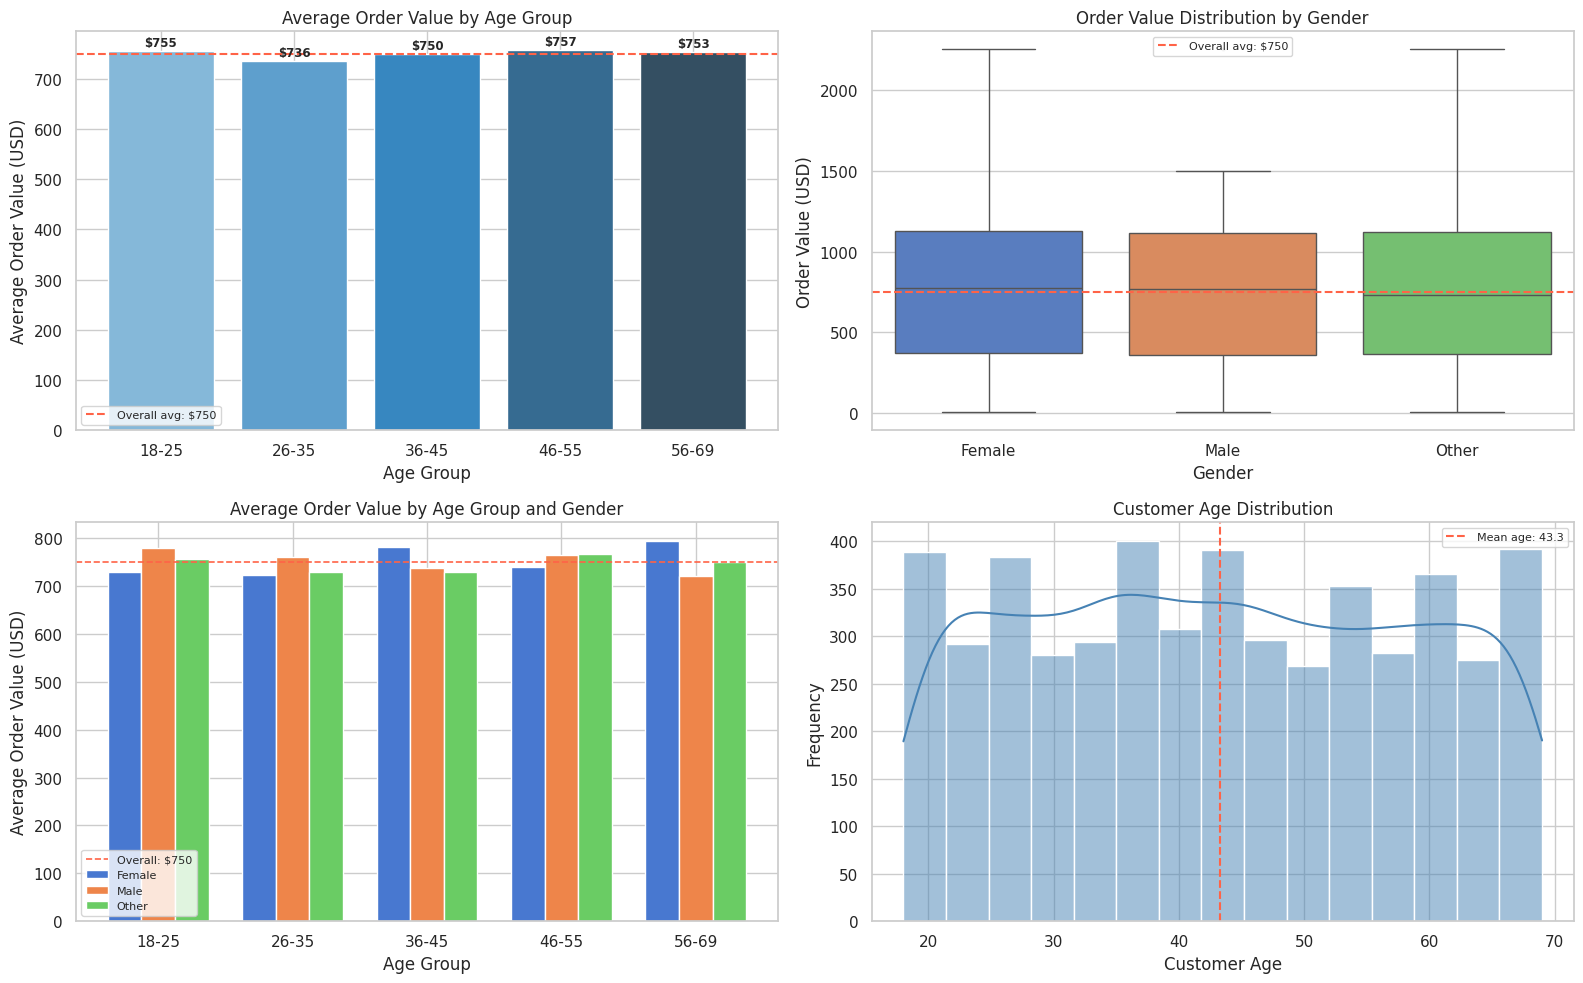

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
overall_mean = df["order_value_usd"].mean()
gender_order = sorted(df["customer_gender"].dropna().unique())

# Chart 1: Average order value by age group
age_vals = aov_by_age["avg_order_value"].reindex(age_order)

bars = axes[0].bar(
    age_vals.index,
    age_vals.values,
    color=sns.color_palette("Blues_d", len(age_vals)),
    edgecolor="white"
)

axes[0].axhline(
    overall_mean,
    color="tomato",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall avg: ${overall_mean:.0f}"
)

for bar, val in zip(bars, age_vals.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f"${val:.0f}",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold"
    )

axes[0].set_title("Average Order Value by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Average Order Value (USD)")
axes[0].legend(fontsize=8)

# Chart 2: Boxplot order value by gender
sns.boxplot(
    data=df,
    x="customer_gender",
    y="order_value_usd",
    order=gender_order,
    palette="muted",
    ax=axes[1],
    flierprops={
        "markerfacecolor": "gray",
        "markersize": 2,
        "alpha": 0.3
    }
)

axes[1].axhline(
    overall_mean,
    color="tomato",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall avg: ${overall_mean:.0f}"
)

axes[1].set_title("Order Value Distribution by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Order Value (USD)")
axes[1].legend(fontsize=8)

# Chart 3: Grouped bar — age group × gender
colors_g = sns.color_palette("muted", len(gender_order))
x = np.arange(len(age_order))
width = 0.25

for i, gender in enumerate(gender_order):
    vals = [
        aov_age_gender.loc[ag, gender]
        if ag in aov_age_gender.index and gender in aov_age_gender.columns
        else 0
        for ag in age_order
    ]
    axes[2].bar(
        x + i * width,
        vals,
        width,
        label=gender,
        color=colors_g[i],
        edgecolor="white"
    )

axes[2].set_xticks(x + width)
axes[2].set_xticklabels(age_order)
axes[2].axhline(
    overall_mean,
    color="tomato",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall: ${overall_mean:.0f}"
)

axes[2].set_title("Average Order Value by Age Group and Gender")
axes[2].set_xlabel("Age Group")
axes[2].set_ylabel("Average Order Value (USD)")
axes[2].legend(fontsize=8)

#chart 4
sns.histplot(
    data=df,
    x="customer_age",
    bins=15,
    kde=True,
    color="steelblue",
    edgecolor="white",
    ax=axes[3]
)

mean_age = df["customer_age"].mean()

axes[3].axvline(
    mean_age,
    color="tomato",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean age: {mean_age:.1f}"
)

axes[3].set_title("Customer Age Distribution")
axes[3].set_xlabel("Customer Age")
axes[3].set_ylabel("Frequency")
axes[3].legend(fontsize=8)




plt.tight_layout()
plt.savefig("chart_rq1.png", dpi=150, bbox_inches="tight")
plt.show()

Chart explanation:
Average order values across age groups are close to the overall mean of $750.
The differences by age and gender appear relatively small in this dataset.
This suggests that demographics alone may not strongly separate spending behavior.

## **RESULT**
Because the p-value is 0.8494, which is much higher than 0.05, there is no statistically significant difference in order value across age groups.The charts also support this result. The average order value across age groups is very close to the overall average of about $750.




---
**Interpretation**

The results suggest that age group does not strongly influence total order value in this dataset.

Although the 46–55 age group has the highest average order value at around $757, and the 26–35 group has the lowest at around $736, the difference is relatively small.

The boxplot by gender also shows that the order value distributions across Female, Male, and Other customers are quite similar. The median values are close to the overall average, and the spread of order values is broadly similar across gender groups.

The grouped bar chart by age group and gender shows some small variations. For example, some gender groups within certain age ranges spend slightly more, but the pattern is not consistent enough to conclude that age or gender is a strong driver of order value

---

**Answer to RQ1**

Based on the ANOVA result and the charts, customer demographics, specifically age and gender, appear to have only a limited influence on total order values in this dataset.

There is no statistically significant difference in order value across age groups. Gender-based differences also appear relatively small from the boxplot and grouped bar chart.

Therefore, demographics alone may not be enough to explain customer spending behavior.

---
**Managerial implication**

For managers, this means that targeting customers based only on age or gender may not be the most effective strategy for increasing order value.

Instead, e-commerce businesses should combine demographic information with other behavioral variables, such as:

Product category
Payment method
Order value segment
Return behavior
Customer rating
Delivery performance

This would allow the business to build more meaningful customer segments and design more effective marketing campaigns.

# **C. RQ2 — Payment Method, Purchasing Behavior and Return Likelihood**
Does payment method affect purchasing behavior and return likelihood?

## **I. RQ2 Summary Table**
Create a summary table by payment method

In [ ]:
payment_summary = df.groupby("payment_method").agg(
    order_count=("order_id", "count"),
    avg_order_value=("order_value_usd", "mean"),
    median_order_value=("order_value_usd", "median"),
    total_order_value=("order_value_usd", "sum"),
    returned_orders=("returned_flag", "sum"),
    return_rate=("returned_flag", "mean"),
    avg_rating=("customer_rating", "mean")
).round(2)

payment_summary["return_rate"] = (payment_summary["return_rate"] * 100).round(2)
payment_summary = payment_summary.sort_values("return_rate", ascending=False)

print("Payment method summary:")
display(payment_summary)

Payment method summary:


,order_count,avg_order_value,median_order_value,total_order_value,returned_orders,return_rate,avg_rating
payment_method,,,,,,,
UPI,1008,736.55,741.56,742442.38,534,53.0,3.03
Cash on Delivery,932,759.59,784.16,707936.26,481,52.0,3.06
Credit Card,1070,762.79,767.45,816180.45,535,50.0,2.99
Debit Card,972,733.60,724.72,713060.11,479,49.0,3.03
Wallet,989,758.50,769.23,750155.57,481,49.0,2.98


This table helps answer whether payment method is associated with different purchasing behavior and return likelihood\

A payment method with a higher return rate may indicate higher return risk. A payment method with higher average order value may indicate stronger purchasing behavior. These patterns can help managers monitor payment-related customer behavior and evaluate checkout policies.

## **II. RQ2 Charts**
Create three charts for RQ2:\
1.Return rate by payment method\
2.Average order value by payment method\
3.Order count by payment method

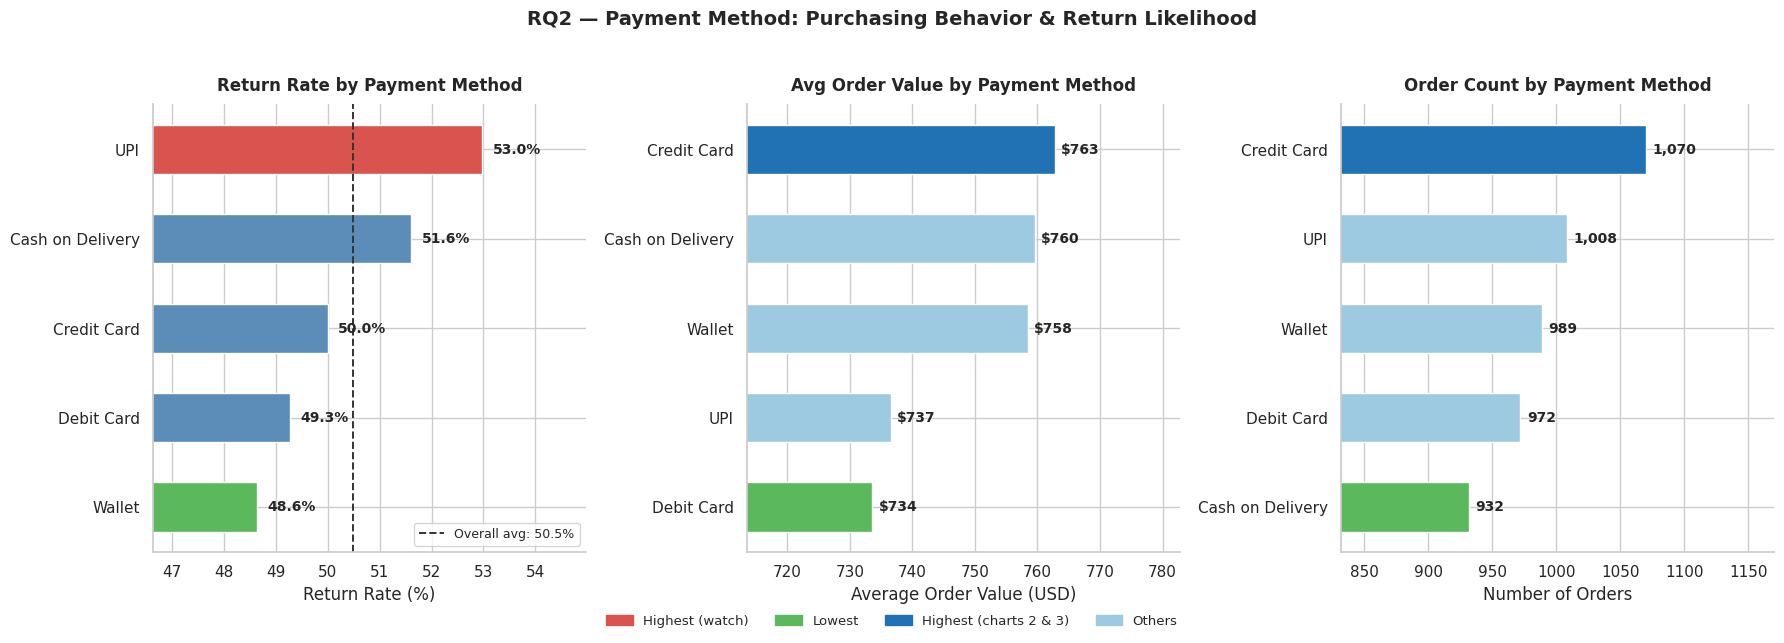

Saved: chart_rq2_payment.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#prepare data from dataframe
payment_summary = (
    df.groupby("payment_method")
    .agg(
        return_rate=("returned_flag", lambda x: x.mean() * 100),
        avg_order_value=("order_value_usd", "mean"),
        order_count=("returned_flag", "count") ))

overall_return = df["returned_flag"].mean() * 100

#color functions
def return_colors(values):
    mx, mn = max(values), min(values)
    return [
        "#d9534f" if v == mx
        else "#5cb85c" if v == mn
        else "#5b8db8"
        for v in values ]

def aov_colors(values):
    mx, mn = max(values), min(values)
    return [
        "#2171b5" if v == mx
        else "#5cb85c" if v == mn
        else "#9ecae1"
        for v in values ]

def count_colors(values):
    mx, mn = max(values), min(values)
    return [
        "#2171b5" if v == mx
        else "#5cb85c" if v == mn
        else "#9ecae1"
        for v in values ]

#sort data for each chart
pay_sorted_return = payment_summary.sort_values("return_rate")
pay_sorted_aov = payment_summary.sort_values("avg_order_value")
pay_sorted_count = payment_summary.sort_values("order_count")

#figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fig.suptitle(
    "RQ2 — Payment Method: Purchasing Behavior & Return Likelihood",
    fontsize=14,
    fontweight="bold",
    y=1.02 )

# chart 1: Return Rate
ax = axes[0]

rr_labels = pay_sorted_return.index
rr_vals = pay_sorted_return["return_rate"]

bars = ax.barh(
    rr_labels,
    rr_vals,
    color=return_colors(rr_vals),
    edgecolor="white",
    height=0.55 )

ax.axvline(
    overall_return,
    color="#333333",
    linestyle="--",
    linewidth=1.4,
    label=f"Overall avg: {overall_return:.1f}%" )

for bar, val in zip(bars, rr_vals):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=10,
        fontweight="bold" )

ax.set_xlim(rr_vals.min() - 2, rr_vals.max() + 2)

ax.set_title(
    "Return Rate by Payment Method",
    fontsize=12,
    fontweight="bold",
    pad=10 )

ax.set_xlabel("Return Rate (%)")
ax.legend(fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

#chart 2: Average Order Value
ax = axes[1]

aov_labels = pay_sorted_aov.index
aov_vals = pay_sorted_aov["avg_order_value"]

bars2 = ax.barh(
    aov_labels,
    aov_vals,
    color=aov_colors(aov_vals),
    edgecolor="white",
    height=0.55 )

for bar, val in zip(bars2, aov_vals):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"${val:,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold" )

ax.set_xlim(aov_vals.min() - 20, aov_vals.max() + 20)

ax.set_title(
    "Avg Order Value by Payment Method",
    fontsize=12,
    fontweight="bold",
    pad=10 )

ax.set_xlabel("Average Order Value (USD)")
ax.spines[["top", "right"]].set_visible(False)

# chart 3: Order Count
ax = axes[2]

cnt_labels = pay_sorted_count.index
cnt_vals = pay_sorted_count["order_count"]

bars3 = ax.barh(
    cnt_labels,
    cnt_vals,
    color=count_colors(cnt_vals),
    edgecolor="white",
    height=0.55
)

for bar, val in zip(bars3, cnt_vals):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(val):,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlim(cnt_vals.min() - 100, cnt_vals.max() + 100)

ax.set_title(
    "Order Count by Payment Method",
    fontsize=12,
    fontweight="bold",
    pad=10
)

ax.set_xlabel("Number of Orders")
ax.spines[["top", "right"]].set_visible(False)

legend_patches = [
    mpatches.Patch(color="#d9534f", label="Highest (watch)"),
    mpatches.Patch(color="#5cb85c", label="Lowest"),
    mpatches.Patch(color="#2171b5", label="Highest (charts 2 & 3)"),
    mpatches.Patch(color="#9ecae1", label="Others"),
]

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=4,
    fontsize=9.5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.03)
)

plt.tight_layout()

plt.savefig(
    "chart_rq2_payment.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved: chart_rq2_payment.png")

ANOVA test


In [ ]:
from scipy.stats import f_oneway

groups = [
    g["order_value_usd"].dropna()
    for _, g in df.groupby("payment_method")
]

f_stat, p = f_oneway(*groups)

print(f"F={f_stat:.3f}")
print(f"p={p:.5f}")

F=1.036
p=0.38719


Chi Square Test

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# Contingency table
contingency = pd.crosstab(
    df["payment_method"],
    df["returned_flag"]
)

print("Contingency Table:")
display(contingency)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p:.5f}")

# Expected frequencies
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

print("\nExpected Frequencies:")
display(expected_df.round(2))

alpha = 0.05

if p < alpha:
    print("Reject H0 → Payment method is significantly associated with return behavior.")
else:
    print("Fail to reject H0 → No significant association between payment method and return behavior.")

Contingency Table:


returned_flag,0,1
payment_method,,
Cash on Delivery,451,481
Credit Card,535,535
Debit Card,493,479
UPI,474,534
Wallet,508,481


Chi-square statistic: 4.993
Degrees of freedom: 4
P-value: 0.28798

Expected Frequencies:


returned_flag,0,1
payment_method,,
Cash on Delivery,461.41,470.59
Credit Card,529.73,540.27
Debit Card,481.21,490.79
UPI,499.03,508.97
Wallet,489.63,499.37


Fail to reject H0 → No significant association between payment method and return behavior.


To investigate whether payment method influences customer purchasing behavior and return likelihood, two statistical analyses were conducted. A one-way ANOVA examined differences in purchasing behavior using order value across payment methods and found no statistically significant difference (F = 1.036, p = .387). In addition, a Chi-square test of independence showed no significant association between payment method and return behavior (χ²(4) = 4.993, p = .288). Therefore, there is insufficient evidence to conclude that payment method affects either purchasing behavior or customers’ likelihood of returning products.

## **RESULT**
The overall return rate is around 50.5%. Compared with this benchmark:

UPI has the highest return rate at 53.0%
Cash on Delivery also has an above-average return rate at 52.0%
Credit Card is close to the overall average at 50.0%
Debit Card and Wallet have the lowest return rates at 49.0%

For purchasing behavior:

Credit Card has the highest average order value at about 763\
Cash on Delivery and Wallet are close behind at about 760 and 759\
Debit Card has the lowest average order value at about 734\
Credit Card also has the highest order count with 1,070 orders


---

**Interpretation**\
Descriptive results show some observable differences in return rate, average order value, and order count across payment methods. UPI has the highest observed return rate, while Credit Card has the highest order count and average order value.

However, the ANOVA test for order value and the Chi-square test for return behavior both show p-values greater than 0.05. Therefore, there is insufficient statistical evidence to conclude that payment method significantly affects purchasing behavior or return likelihood in this dataset.

Payment method can still be used as a useful monitoring signal, but it should not be treated as a confirmed driver of return behavior.

For return likelihood, UPI and Cash on Delivery are slightly above the platform average return rate. This means customers using these payment methods are somewhat more likely to return products compared with customers using Debit Card or Wallet.

For purchasing behavior, Credit Card users show the highest average order value and the largest number of orders. This suggests Credit Card may be an important payment method for revenue generation.

However, the gap in return rates is only around 4 percentage points between the highest group, UPI at 53.0%, and the lowest groups, Debit Card and Wallet at 49.0%. Therefore, payment method may be a useful monitoring signal, but it should not be treated as the only factor explaining returns.


---



**Answer to RQ2**\
Descriptive results show some observable differences in purchasing behavior and return likelihood across payment methods. However, the ANOVA test for order value and the Chi-square test for return behavior both show p-values greater than 0.05. Therefore, there is insufficient statistical evidence to conclude that payment method significantly affects purchasing behavior or return likelihood in this dataset.

Different payment methods show differences in:
Order volume,
Average order value,
Number of returned orders,
Return rate

However, the differences are moderate rather than very large. The results suggest that payment method can help identify patterns in customer behavior, but it should be combined with other variables such as product category, order value segment, delivery speed, and customer rating for stronger analysis.


---



**Managerial implication**

For managers, the key point is that payment method can be used as an additional signal for monitoring customer behavior and return risk.

Possible implications:

Since UPI and Cash on Delivery show higher return rates, businesses may monitor these payment methods more closely.
Since Credit Card has the highest order count and average order value, it may be important for revenue and should remain convenient for customers.
Payment-related patterns should be combined with product category and customer behavior before making policy decisions.
Businesses should avoid assuming that one payment method directly causes returns, because EDA shows association, not causation.

---
**Conclusion**\
Payment methods show observable but statistically insignificant differences in purchasing behavior and return likelihood. Therefore, payment method can be used as a monitoring signal, but it should not be treated as a confirmed driver of return behavior in this datase


# **D. RQ3 — Product Categories and Return Frequency**
Which product categories experience the highest frequency of returns?





## **I. RQ3 Summary Tables**
Create product category summary tables including:

Total orders,
Returned orders,
Return rate,
Average order value,
Average rating

In [ ]:
category_summary = df.groupby("product_category").agg(
    total_orders=("order_id", "count"),
    returned_orders=("returned_flag", "sum"),
    return_rate=("returned_flag", "mean"),
    avg_order_value=("order_value_usd", "mean"),
    avg_rating=("customer_rating", "mean")
).round(2)

category_summary["return_rate"] = (category_summary["return_rate"] * 100).round(2)

print("Product categories by return rate:")
display(category_summary.sort_values("return_rate", ascending=False))

print("\nProduct categories by number of returned orders:")
display(category_summary.sort_values("returned_orders", ascending=False))

Product categories by return rate:


,total_orders,returned_orders,return_rate,avg_order_value,avg_rating
product_category,,,,,
Beauty,845,441,52.0,733.30,3.02
Groceries,829,427,52.0,759.91,3.01
Sports,843,426,51.0,756.17,3.04
Home & Living,798,409,51.0,740.65,2.97
Electronics,811,400,49.0,739.71,3.01
Fashion,845,407,48.0,771.34,3.04



Product categories by number of returned orders:


,total_orders,returned_orders,return_rate,avg_order_value,avg_rating
product_category,,,,,
Beauty,845,441,52.0,733.30,3.02
Groceries,829,427,52.0,759.91,3.01
Sports,843,426,51.0,756.17,3.04
Home & Living,798,409,51.0,740.65,2.97
Fashion,845,407,48.0,771.34,3.04
Electronics,811,400,49.0,739.71,3.01


The two rankings are important because return frequency and return rate are not always the same.

A product category may have a high return rate but a relatively small number of orders. Another category may have a lower return rate but a higher number of returned orders due to a larger order volume.

This helps managers identify which product categories should be prioritized for return reduction strategies.

## **II. RQ3 Charts**
Create three charts for RQ3:
1.Return rate by product category\
2.Number of returned orders by category\
3.Total orders vs returned orders by category\

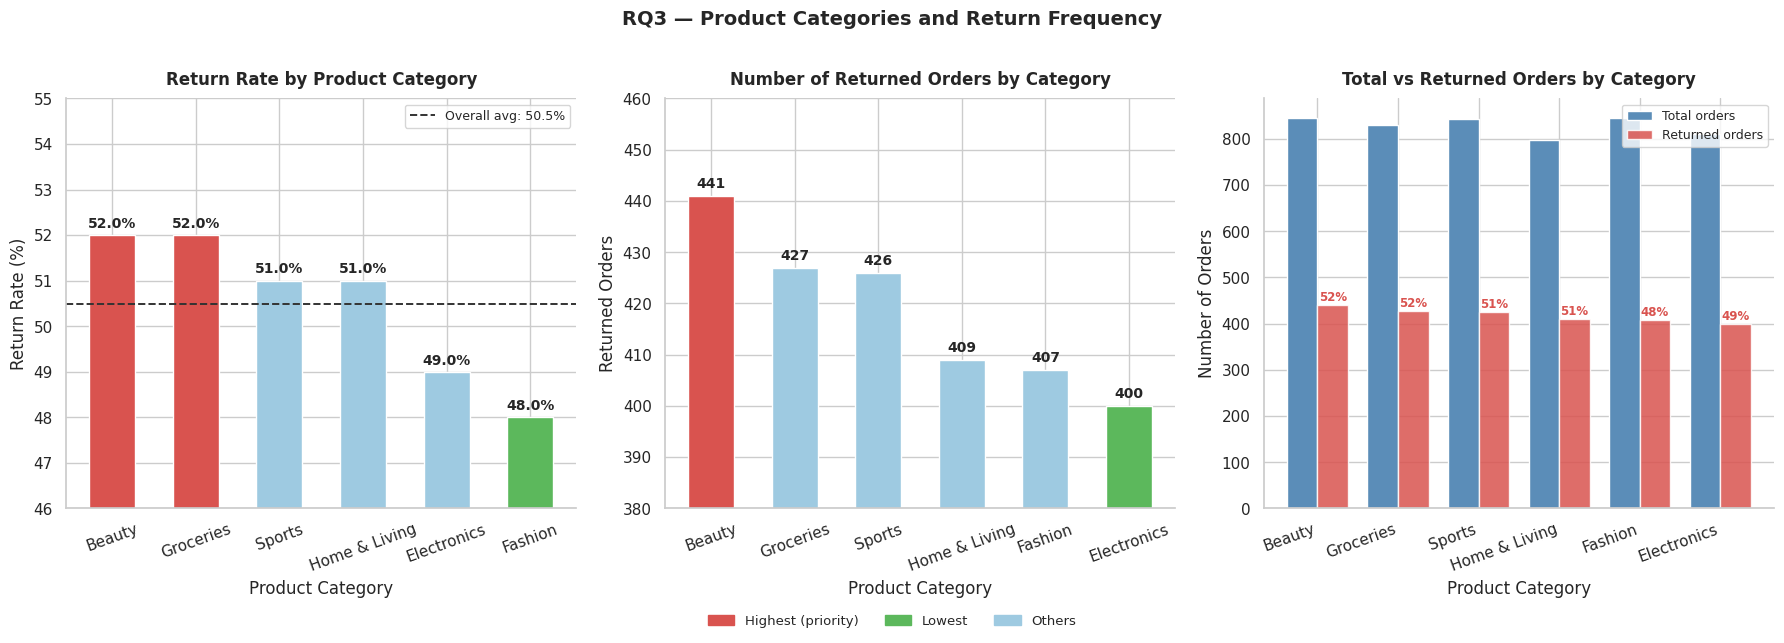

Saved: chart_rq3.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

cat_by_rate  = category_summary.sort_values("return_rate", ascending=False)
cat_by_count = category_summary.sort_values("returned_orders", ascending=False)

def bar_colors(values, high_color="#d9534f", low_color="#5cb85c", mid_color="#9ecae1"):
    mx, mn = max(values), min(values)
    return [high_color if v == mx else low_color if v == mn else mid_color for v in values]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("RQ3 — Product Categories and Return Frequency",
             fontsize=14, fontweight="bold", y=1.01)

#chart 1: Return Rate
ax = axes[0]
vals1  = cat_by_rate["return_rate"].values
colors1 = bar_colors(vals1)
bars1  = ax.bar(cat_by_rate.index, vals1, color=colors1, edgecolor="white", width=0.55)

ax.axhline(overall_return, color="#333", linestyle="--", linewidth=1.4,
           label=f"Overall avg: {overall_return:.1f}%")

for bar, val in zip(bars1, vals1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# zoom y-axis so small differences stand out
ax.set_ylim(46, 55)
ax.set_title("Return Rate by Product Category", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Product Category")
ax.set_ylabel("Return Rate (%)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

#chart 2: Number of Returned Orders
ax = axes[1]
vals2   = cat_by_count["returned_orders"].values
colors2 = bar_colors(vals2)
bars2   = ax.bar(cat_by_count.index, vals2, color=colors2, edgecolor="white", width=0.55)

for bar, val in zip(bars2, vals2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{int(val)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# zoom y-axis
ax.set_ylim(380, 460)
ax.set_title("Number of Returned Orders by Category", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Product Category")
ax.set_ylabel("Returned Orders")
ax.tick_params(axis="x", rotation=20)
ax.spines[["top", "right"]].set_visible(False)

#chart 3: Total vs Returned Orders (grouped bar + return rate annotation) ─
ax = axes[2]
x = np.arange(len(cat_by_count.index))
w = 0.38

ax.bar(x - w / 2, cat_by_count["total_orders"],   w,
       label="Total orders",    color="#5b8db8", edgecolor="white")
ax.bar(x + w / 2, cat_by_count["returned_orders"], w,
       label="Returned orders", color="#d9534f", edgecolor="white", alpha=0.85)

# annotate return rate % on top of each returned bar
for i, (idx, row) in enumerate(cat_by_count.iterrows()):
    ax.text(i + w / 2, row["returned_orders"] + 3,
            f'{row["return_rate"]:.0f}%',
            ha="center", va="bottom", fontsize=8.5,
            color="#d9534f", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(cat_by_count.index, rotation=20, ha="right")
ax.set_title("Total vs Returned Orders by Category", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Product Category")
ax.set_ylabel("Number of Orders")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

#shared legend
legend_patches = [
    mpatches.Patch(color="#d9534f", label="Highest (priority)"),
    mpatches.Patch(color="#5cb85c", label="Lowest"),
    mpatches.Patch(color="#9ecae1", label="Others"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=3,
           fontsize=9.5, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("chart_rq3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart_rq3.png")

## **RESULT**

The highest return rates are found in:

Beauty: 52.0%,
Groceries: 52.0%,
Sports: 51.0%,
Home & Living: 51.0%

The highest number of returned orders is:

Beauty: 441 returned orders,
Groceries: 427 returned orders,
Sports: 426 returned orders

The overall return rate is around 50.5%, so Beauty and Groceries are slightly above the overall average.





---

**Interpretation**\
The results show that product categories differ in return behavior, but the differences are not extremely large.

Beauty is the most important category from a return-management perspective because it has both:

The highest number of returned orders: 441
One of the highest return rates: 52.0%

Groceries also has a high return rate of 52.0% and the second-highest number of returned orders at 427.

Fashion has the lowest return rate at 48.0%, even though it has one of the highest average order values at $771.34. This is interesting because Fashion is often expected to have high returns in many e-commerce contexts, but in this dataset, Fashion does not show the highest return issue.

Electronics also has a below-average return rate at 49.0%, with 400 returned orders


---
**Answer to RQ3**\
The product category with the highest frequency of returns is Beauty, with 441 returned orders. It also has one of the highest return rates at 52.0%.

Other high-return categories include Groceries and Sports, with 427 and 426 returned orders respectively.

Therefore, Beauty should be the first category prioritized for return reduction strategies, followed by Groceries and Sports.

---
**Managerial implication**

For managers, the key implication is that return management should focus first on categories with both high return frequency and high return rate.

Recommended actions:

Review product descriptions in high-return categories\
Improve product images and specifications\
Check whether customer expectations match the actual product\
Strengthen quality control for Beauty and Groceries\
Analyze customer complaints or reviews for high-return categories\
Monitor whether returns are caused by product quality, inaccurate descriptions, delivery issues, or customer preference changes

Since Beauty has the highest return volume and one of the highest return rates, it should be treated as a priority category for operational improvement


---

**Conclusion**

Beauty is the highest-priority product category for return management because it has both the highest number of returned orders and one of the highest return rates. Groceries and Sports also require attention due to their high return volumes. However, the differences in return rates across categories are moderate, so managers should combine return rate with return frequency when deciding which categories to improve first.

# **E. RQ4 — Delivery Duration and Customer Ratings**
What is the relationship between delivery duration and customer ratings?





## **I. RQ4 Summary and Correlation**
Create a delivery performance summary and calculate the Pearson correlation between delivery_time_days and customer_rating.

In [ ]:
delivery_order = ["Fast delivery", "Standard delivery", "Slow delivery"]

delivery_summary = df.groupby("delivery_speed").agg(
    order_count=("order_id", "count"),
    avg_delivery_time=("delivery_time_days", "mean"),
    avg_rating=("customer_rating", "mean"),
    median_rating=("customer_rating", "median"),
    return_rate=("returned_flag", "mean")
).reindex(delivery_order).round(2)

delivery_summary["return_rate"] = (delivery_summary["return_rate"] * 100).round(2)

print("Delivery performance summary:")
display(delivery_summary)

r, p = stats.pearsonr(df["delivery_time_days"], df["customer_rating"])

print("\nPearson correlation between delivery time and customer rating:")
print(f"r = {r:.4f}")
print(f"p = {p:.4f}")

if abs(r) < 0.1:
    print("Interpretation: The relationship appears very weak in this dataset.")
elif abs(r) < 0.3:
    print("Interpretation: The relationship appears weak.")
else:
    print("Interpretation: The relationship appears moderate or stronger.")

avg_by_day = df.groupby("delivery_time_days")["customer_rating"].mean().round(3)

print("\nAverage rating by delivery day:")
display(avg_by_day)

Delivery performance summary:


,order_count,avg_delivery_time,avg_rating,median_rating,return_rate
delivery_speed,,,,,
Fast delivery,1053,2.00,3.09,3.1,51.0
Standard delivery,1495,5.55,3.01,3.0,49.0
Slow delivery,2423,11.02,2.99,3.0,51.0



Pearson correlation between delivery time and customer rating:
r = -0.0207
p = 0.1445
Interpretation: The relationship appears very weak in this dataset.

Average rating by delivery day:


,customer_rating
delivery_time_days,
1,3.062
2,3.034
3,3.161
4,3.071
5,2.967
6,2.982
7,3.020
8,2.916
9,2.873


The correlation coefficient shows the strength and direction of the relationship between delivery duration and customer rating.

If the correlation is close to zero, the relationship is weak. This means that delivery duration alone may not strongly explain customer ratings in this dataset. However, delivery performance may still be important in real business contexts and should be monitored together with other factors.


## **II. RQ4 Charts**
1.Average customer rating by delivery speed\
2.Rating distribution by delivery speed\
3.Delivery time vs customer rating

/tmp/ipykernel_1680/1720089730.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


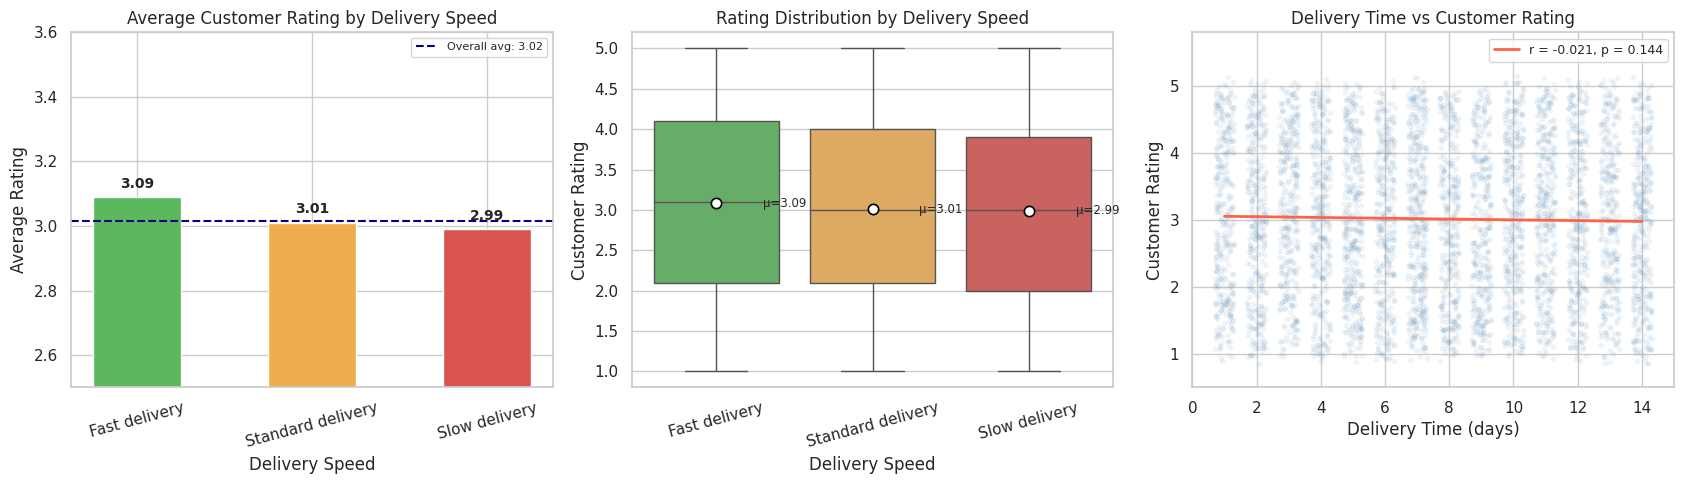


Chart explanation:
Fast delivery average rating: 3.09
Slow delivery average rating: 2.99
Difference: 0.09 points on a 1–5 scale.
The relationship between delivery time and rating appears weak in this dataset.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

delivery_order = ["Fast delivery", "Standard delivery", "Slow delivery"]
palette_speed = {
    "Fast delivery": "#5cb85c",
    "Standard delivery": "#f0ad4e",
    "Slow delivery": "#d9534f"
}

overall_rating = df["customer_rating"].mean()

# Chart 1: Average rating by delivery speed
rating_by_speed = delivery_summary["avg_rating"].reindex(delivery_order)

bars = axes[0].bar(
    delivery_order,
    rating_by_speed.values,
    color=[palette_speed[s] for s in delivery_order],
    edgecolor="white",
    width=0.5
)

axes[0].axhline(
    overall_rating,
    color="navy",
    linestyle="--",
    linewidth=1.5,
    label=f"Overall avg: {overall_rating:.2f}"
)

for bar, val in zip(bars, rating_by_speed.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

axes[0].set_title("Average Customer Rating by Delivery Speed")
axes[0].set_xlabel("Delivery Speed")
axes[0].set_ylabel("Average Rating")
axes[0].set_ylim(2.5, 3.6)
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(fontsize=8)

# Chart 2: Boxplot rating by delivery speed
sns.boxplot(
    data=df,
    x="delivery_speed",
    y="customer_rating",
    order=delivery_order,
    palette=palette_speed,
    ax=axes[1],
    flierprops={
        "markerfacecolor": "gray",
        "markersize": 2,
        "alpha": 0.3
    }
)

for i, speed in enumerate(delivery_order):
    m = df[df["delivery_speed"] == speed]["customer_rating"].mean()
    axes[1].scatter(
        i,
        m,
        color="white",
        s=55,
        zorder=5,
        edgecolors="black",
        linewidths=1.2
    )
    axes[1].text(i + 0.3, m, f"μ={m:.2f}", va="center", fontsize=8.5)

axes[1].set_title("Rating Distribution by Delivery Speed")
axes[1].set_xlabel("Delivery Speed")
axes[1].set_ylabel("Customer Rating")
axes[1].tick_params(axis="x", rotation=15)

# Chart 3: Scatter delivery time vs rating
np.random.seed(42)

jx = df["delivery_time_days"] + np.random.uniform(-0.3, 0.3, len(df))
jy = df["customer_rating"] + np.random.uniform(-0.15, 0.15, len(df))

axes[2].scatter(jx, jy, alpha=0.07, s=9, color="#5b8db8")

m_lr, b_lr, r_lr, p_lr, _ = stats.linregress(
    df["delivery_time_days"],
    df["customer_rating"]
)

x_line = np.linspace(1, 14, 100)

axes[2].plot(
    x_line,
    m_lr * x_line + b_lr,
    color="tomato",
    linewidth=2,
    label=f"r = {r_lr:.3f}, p = {p_lr:.3f}"
)

axes[2].set_title("Delivery Time vs Customer Rating")
axes[2].set_xlabel("Delivery Time (days)")
axes[2].set_ylabel("Customer Rating")
axes[2].set_xlim(0, 15)
axes[2].set_ylim(0.5, 5.8)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("chart_rq4.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nChart explanation:")
fast_m = df[df["delivery_speed"] == "Fast delivery"]["customer_rating"].mean()
slow_m = df[df["delivery_speed"] == "Slow delivery"]["customer_rating"].mean()

print(f"Fast delivery average rating: {fast_m:.2f}")
print(f"Slow delivery average rating: {slow_m:.2f}")
print(f"Difference: {fast_m - slow_m:.2f} points on a 1–5 scale.")
print("The relationship between delivery time and rating appears weak in this dataset.")

**RESULT**\
The highest average rating is found in the Fast delivery group, with an average rating of 3.09.\
The lowest average rating is found in the Slow delivery group, with an average rating of 2.99.\
Therefore, the difference is: 0.1 points.\
The Pearson correlation result is: r = -0.0207; p = 0.144\
This means the relationship between delivery time and customer rating is very weak and not statistically significant at the 0.05 level.


---
**Interpretation**\
The results show a slight pattern where faster delivery has a marginally higher average rating. Fast delivery has an average rating of 3.09, while slow delivery has an average rating of 2.99.

However, the difference is very small. A difference of 0.10 points on a 1–5 scale is unlikely to represent a strong practical difference.

The scatter plot also supports this interpretation. The points are widely spread across all delivery times, and the regression line is almost flat. This suggests that customer ratings do not clearly decrease as delivery time increases.

The correlation coefficient of -0.0207 is very close to zero, meaning there is almost no linear relationship between delivery duration and customer rating in this dataset.

The p-value of 0.1445 is greater than 0.05, so the relationship is not statistically significant.\


**Answer to RQ4**\
Delivery duration appears to have only a very weak relationship with customer ratings in this dataset.

Although fast delivery has the highest average rating, the difference between fast and slow delivery is small. The correlation result also shows that delivery time is not strongly associated with customer rating.

Therefore, delivery duration alone does not appear to be a strong predictor of customer satisfaction in this dataset.


---



**Managerial implication**
For managers, the result suggests that improving delivery speed alone may not lead to a large improvement in customer ratings.

This does not mean delivery performance is unimportant. Delivery should still be monitored because it is part of customer experience. However, customer satisfaction may also depend on other factors that are not directly captured in this dataset, such as:

Product quality
Accuracy of product descriptions
Packaging condition
Customer expectations
After-sales service
Return process convenience

Therefore, managers should not focus only on reducing delivery time. They should combine delivery performance monitoring with broader customer satisfaction analysis

---

**Conclusion**\
Fast delivery has a slightly higher average customer rating than standard and slow delivery, but the difference is very small. The Pearson correlation between delivery time and customer rating is -0.0207, with a p-value of 0.1445, indicating a very weak and statistically insignificant relationship. Therefore, delivery duration alone does not strongly explain customer ratings in this dataset.




# **F. Trend & Correlation Analysis**


## **I. Trend Analysis**
Analyzes changes over time using the order_date variable.

Yearly summary:


,order_count,return_rate,avg_order_value
order_year,,,
2022,361,51.0,760.17
2023,362,50.0,780.26
2024,363,47.0,729.43
2025,363,52.0,750.99
2026,363,52.0,740.09
2027,364,53.0,752.68
2028,363,49.0,733.82
2029,362,49.0,738.00
2030,368,55.0,724.42


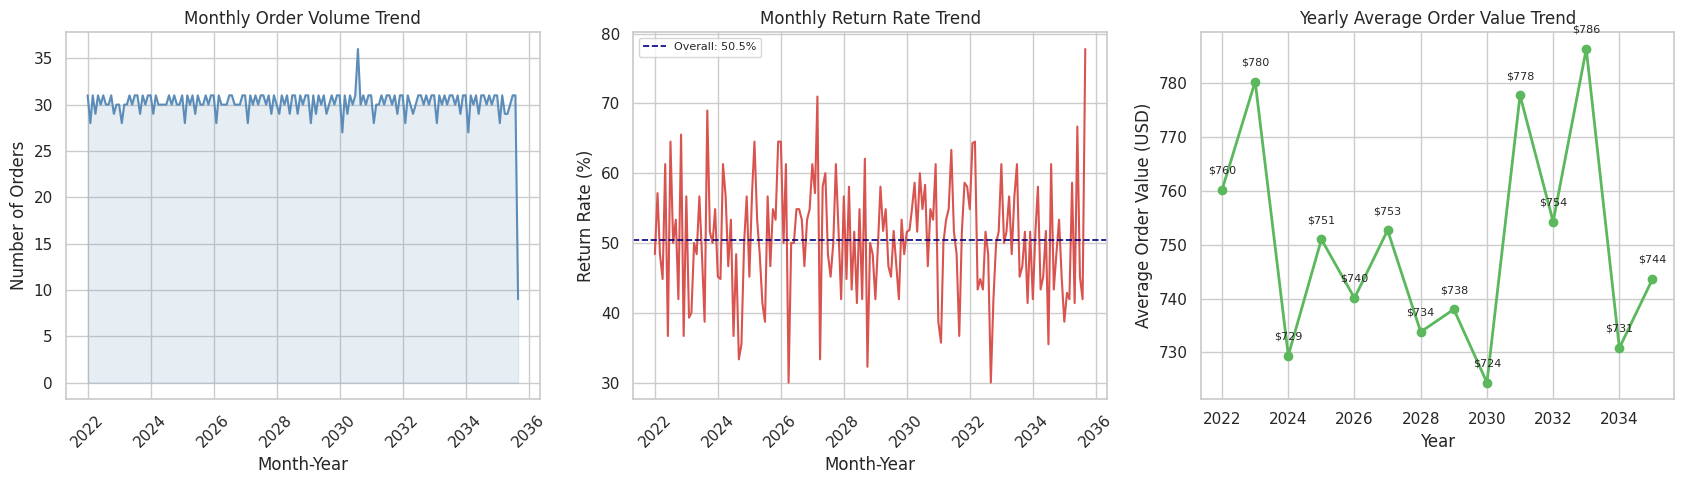


Trend explanation:
The trend charts provide a time-based view of order volume, return rate, and average order value.
Because the dataset appears to be simulated, trend interpretation should focus on analytical practice rather than real-time business forecasting.


In [ ]:
monthly = df.groupby("order_month_year").agg(
    order_count=("order_id", "count"),
    returned_orders=("returned_flag", "sum"),
    return_rate=("returned_flag", "mean"),
    avg_order_value=("order_value_usd", "mean")
).reset_index()

monthly["return_rate"] = (monthly["return_rate"] * 100).round(2)
monthly["avg_order_value"] = monthly["avg_order_value"].round(2)
monthly["date"] = pd.to_datetime(monthly["order_month_year"])
monthly = monthly.sort_values("date")

yearly = df.groupby("order_year").agg(
    order_count=("order_id", "count"),
    return_rate=("returned_flag", "mean"),
    avg_order_value=("order_value_usd", "mean")
).round(2)

yearly["return_rate"] = (yearly["return_rate"] * 100).round(2)

print("Yearly summary:")
display(yearly)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Chart 1: Monthly order volume
axes[0].plot(
    monthly["date"],
    monthly["order_count"],
    color="#5b8db8",
    linewidth=1.5
)

axes[0].fill_between(
    monthly["date"],
    monthly["order_count"],
    alpha=0.15,
    color="#5b8db8"
)

axes[0].set_title("Monthly Order Volume Trend")
axes[0].set_xlabel("Month-Year")
axes[0].set_ylabel("Number of Orders")
axes[0].tick_params(axis="x", rotation=45)

# Chart 2: Monthly return rate
axes[1].plot(
    monthly["date"],
    monthly["return_rate"],
    color="#d9534f",
    linewidth=1.5
)

axes[1].axhline(
    df["returned_flag"].mean() * 100,
    color="navy",
    linestyle="--",
    linewidth=1.2,
    label=f"Overall: {df['returned_flag'].mean() * 100:.1f}%"
)

axes[1].set_title("Monthly Return Rate Trend")
axes[1].set_xlabel("Month-Year")
axes[1].set_ylabel("Return Rate (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(fontsize=8)

# Chart 3: Yearly average order value
axes[2].plot(
    yearly.index,
    yearly["avg_order_value"],
    marker="o",
    color="#5cb85c",
    linewidth=2,
    markersize=6
)

for x, y in zip(yearly.index, yearly["avg_order_value"]):
    axes[2].text(x, y + 3, f"${y:.0f}", ha="center", fontsize=8)

axes[2].set_title("Yearly Average Order Value Trend")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Average Order Value (USD)")

plt.tight_layout()
plt.savefig("chart_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTrend explanation:")
print("The trend charts provide a time-based view of order volume, return rate, and average order value.")
print("Because the dataset appears to be simulated, trend interpretation should focus on analytical practice rather than real-time business forecasting.")

**RESULT**\
Most years have around 361–368 orders, except 2035, which has 249 orders. This likely happens because the dataset does not cover the full year 2035.

2. Monthly order volume trend

The monthly order volume chart is very stable. Most months have around 28–31 orders.

There is one visible spike around 2030 with about 36 orders, and a clear drop at the end of the timeline. The final drop is likely because the dataset ends before a full month or full year is completed.

This suggests that the dataset has a relatively balanced number of orders over time, rather than strong seasonal fluctuations.

3. Monthly return rate trend

The monthly return rate fluctuates much more than order volume.

Most monthly return rates move around the overall average of about 50.5%, but there are noticeable short-term fluctuations. Some months fall close to 30–40%, while others rise above 60%.

This indicates that return behavior is more volatile over time than order volume. However, because monthly order counts are relatively small, monthly return rate fluctuations should be interpreted carefully.

4. Yearly average order value trend

Yearly average order value changes across years, but there is no clear upward or downward trend.

The highest yearly average order value is in 2033: around 786

The lowest yearly average order value is in 2030: around 724

The difference between the highest and lowest yearly average order value is about: 786 - 724 = 62

This shows some year-to-year variation in spending, but not a consistent long-term trend.

---
**Interpretation**\
Overall, the trend analysis suggests:
Order volume is relatively stable over time.\
Return rate fluctuates month by month around the overall average.\
Average order value varies by year, but without a clear upward or downward pattern.\
The 2035 order count is lower because the dataset likely does not include the full year.\
Since the dataset extends to future years, it should be interpreted as a simulated academic dataset rather than real business forecasting data\


---
**Managerial implication**\
For managers, the main implication is that return rate should be monitored regularly, even when order volume is stable.

Stable order volume does not mean return behavior is stable. Some months may still experience higher return rates, which could affect profitability and reverse logistics costs.

A business dashboard should track:

Monthly order volume\
Monthly return rate\
Average order value\
Product category returns\
Payment method return patterns\

This would help managers detect abnormal return patterns earlier and investigate possible cause

---
**Conclusion**\
Order volume remains relatively stable over time, but monthly return rates fluctuate around the overall average of 50.5%. Yearly average order value varies between about 724 and 786, without a clear long-term upward or downward trend. Since the dataset appears simulated and extends to future years, the trend analysis should be interpreted as an academic exercise rather than a real-time business forecast.




## **II. Correlation Analysis**
Creates a correlation matrix and heatmap for numerical variables.

Correlation matrix:


,customer_age,order_value_usd,delivery_time_days,customer_rating,returned_flag
customer_age,1.000,0.005,-0.002,0.012,-0.007
order_value_usd,0.005,1.000,0.004,0.014,-0.005
delivery_time_days,-0.002,0.004,1.000,-0.021,0.006
customer_rating,0.012,0.014,-0.021,1.000,0.033
returned_flag,-0.007,-0.005,0.006,0.033,1.000


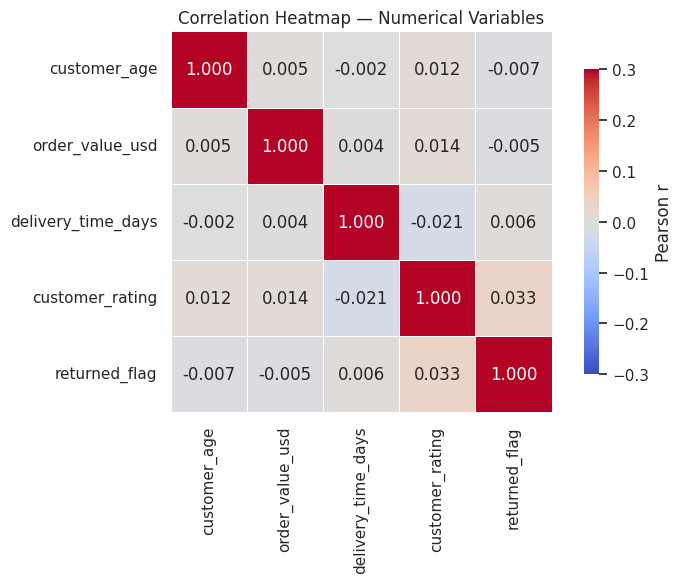


Correlation explanation:
The heatmap shows the strength and direction of relationships among numerical variables.
Values close to zero indicate weak linear relationships.


In [ ]:
numeric_cols = [
    "customer_age",
    "order_value_usd",
    "delivery_time_days",
    "customer_rating",
    "returned_flag"
]

corr_matrix = df[numeric_cols].corr().round(3)

print("Correlation matrix:")
display(corr_matrix)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-0.3,
    vmax=0.3,
    cbar_kws={
        "shrink": 0.8,
        "label": "Pearson r"
    }
)

ax.set_title("Correlation Heatmap — Numerical Variables")

plt.tight_layout()
plt.savefig("chart_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCorrelation explanation:")
print("The heatmap shows the strength and direction of relationships among numerical variables.")
print("Values close to zero indicate weak linear relationships.")

**RESULT**
| Variable pair                               | Correlation | Interpretation                  |
| ------------------------------------------- | ----------: | ------------------------------- |
| `delivery_time_days` and `customer_rating`  |      -0.021 | Very weak negative relationship |
| `returned_flag` and `customer_rating`       |       0.033 | Very weak positive relationship |
| `order_value_usd` and `returned_flag`       |      -0.005 | Almost no relationship          |
| `customer_age` and `order_value_usd`        |       0.005 | Almost no relationship          |
| `delivery_time_days` and `returned_flag`    |       0.006 | Almost no relationship          |

---
**Interpretation**

The heatmap shows that most variables are not strongly correlated.

Most numerical variables show correlations close to zero. This indicates that customer age, order value, delivery time, customer rating, and return status do not have strong linear relationships with each other.

The correlation between delivery_time_days and customer_rating is very weak and negative, supporting the RQ4 finding that delivery duration does not strongly explain customer rating in this dataset.

The correlation between customer_age and order_value_usd is also close to zero, which supports the RQ1 result that age alone is not a strong driver of order value.

Similarly, the correlation between order_value_usd and returned_flag is close to zero, suggesting that order value alone does not strongly explain whether an order is returned.

Overall, the correlation analysis suggests that customer behavior and return likelihood are likely influenced by multiple factors rather than one single numerical variable.

**What this means for the research questions**\
| Research question | Support from correlation analysis                                                                                                                                                          |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| RQ1               | `customer_age` has almost no correlation with `order_value_usd`, supporting the idea that age alone is not a strong driver of order value                                                  |
| RQ2               | Payment method is categorical, so it is not directly shown in this heatmap, but weak correlation between order value and return status suggests return behavior needs group-based analysis |
| RQ3               | Product category is categorical, so return behavior by category should be analyzed using group comparison rather than correlation                                                          |
| RQ4               | `delivery_time_days` has a very weak correlation with `customer_rating`, supporting the conclusion that delivery duration alone does not strongly explain rating                           |


---

**Managerial implication**

For managers, the correlation results suggest that no single numerical variable strongly explains return behavior or customer rating.

This means that return management and customer satisfaction analysis should not rely on one factor only. Instead, businesses should combine multiple types of information, including:

Product category
Payment method
Customer demographics
Delivery speed
Order value segment
Customer rating
Return history

The weak correlations also suggest that group comparison and segmentation are more useful than simple one-variable correlation for this dataset


---
**Conclusion**\
Most numerical variables show weak linear relationships with each other. The only strong correlation is between order_value_usd and is_high_value_order, which is expected because the high-value indicator was created from order value. The weak correlations between delivery time and rating, age and order value, and order value and return status suggest that customer behavior and return likelihood are likely influenced by multiple factors rather than one single numerical variable


# **G. Insights and Managerial Recommendations**


**Key Insights and Interpretation**\
Summarizes the key insights from the EDA and connects them directly to the four research questions. The interpretation is written carefully to avoid overclaiming causality.\
**RQ1: Customer demographics and order value**

The analysis shows that average order values are very similar across age groups and gender groups. The ANOVA test for age groups produced a p-value of 0.8494, which is much higher than 0.05. This means there is no statistically significant difference in order value across age groups.\

Average order values across age groups range from approximately $736 to $757, which is close to the overall average order value of about $750.\

Interpretation:\
Customer demographics, such as age and gender, do not strongly explain spending behavior in this dataset. Therefore, demographic segmentation alone may not be sufficient for predicting high-value customers.\
**RQ2: Payment method and return likelihood**

Payment methods show observable differences in return rate and purchasing behavior, but these differences are not statistically significant based on the ANOVA and Chi-square tests.. UPI has the highest return rate at 53.0%, followed by Cash on Delivery at 52.0%. Meanwhile, Credit Card has the highest order count with 1,070 orders and the highest average order value at around $763.\

Interpretation:\
Descriptive results show some observable differences in return rate and purchasing behavior across payment methods. UPI has the highest observed return rate, while Credit Card has the highest order count and average order value. However, the ANOVA test and Chi-square test both show p-values greater than 0.05. Therefore, there is insufficient statistical evidence to conclude that payment method significantly affects purchasing behavior or return likelihood in this dataset.\
**RQ3: Product category and return frequency**

Product categories differ in both return rate and return frequency. Beauty has the highest number of returned orders, with 441 returned orders, and it also has one of the highest return rates at 52.0%. Groceries and Sports also show high return volumes, with 427 and 426 returned orders respectively.\

Interpretation:\
Return management should consider both return frequency and return rate. Beauty is the highest-priority category because it ranks high on both measures. Groceries and Sports should also be monitored closely due to their high return volumes.\

**RQ4: Delivery duration and customer rating**

Fast delivery has the highest average customer rating at 3.09, while slow delivery has an average rating of 2.99. The difference is only 0.10 points on a 1–5 rating scale. The Pearson correlation between delivery time and customer rating is -0.0207, with a p-value of 0.1445.\

Interpretation:\
The relationship between delivery duration and customer rating appears very weak and is not statistically significant in this dataset. Delivery performance may still matter, but customer satisfaction is likely influenced by other factors such as product quality, expectation accuracy, packaging, after-sales service, or the return process.\
**Additional finding: Trend and correlation analysis**

The trend analysis shows that monthly order volume is relatively stable, mostly around 28–31 orders per month, while monthly return rates fluctuate around the overall average of 50.5%. Yearly average order value ranges from roughly $724 to $786, without a clear upward or downward trend.\

The correlation analysis shows that most numerical variables have weak linear relationships. The only strong correlation is between order_value_usd and is_high_value_order, which is expected because is_high_value_order was created from order_value_usd.\

**Interpretation:**
Customer behavior and return likelihood are unlikely to be explained by one single numerical variable. A more useful approach is to combine demographic, behavioral, product, payment, and delivery variables.\

**Overall Interpretation**

Overall, the EDA suggests that product returns and customer satisfaction are influenced by multiple factors rather than one dominant variable. Demographics alone do not strongly explain order value, payment method shows moderate differences in return likelihood, product category is important for return management, and delivery duration has only a weak relationship with customer rating.\



---
**Section 17 — Managerial Recommendations**\
Translates the EDA findings into practical managerial recommendations. The recommendations are connected to the research questions and remain consistent with the available data.

---
**Recommendation 1: Improve customer segmentation beyond demographics**

Since age and gender show only small differences in average order value, e-commerce businesses should not rely only on demographic segmentation. Instead, managers should combine demographics with behavioral variables such as product category, payment method, order value segment, return behavior, and customer rating.

This can help businesses create more accurate customer segments and design more effective personalized marketing campaigns.

---



**Recommendation 2: Monitor payment methods with higher return rates**

UPI and Cash on Delivery show above-average observed return rates. Managers should monitor these payment methods more closely and investigate whether return behavior is related to checkout experience, payment friction, customer preferences, or return-risk patterns. However, because the ANOVA and Chi-square tests do not show statistically significant relationships, payment method should be used as a monitoring signal rather than a confirmed cause of return behavior. At the same time, Credit Card should remain an important payment option because it has the highest order count and average order value..

This can help businesses identify payment-related return risks while maintaining convenient payment options for valuable customers.

---



**Recommendation 3: Prioritize high-return product categories**

Beauty should be prioritized for return reduction because it has both the highest number of returned orders and one of the highest return rates. Groceries and Sports should also be monitored because they generate high return volumes.

Managers should review product descriptions, product images, specifications, sizing information, quality checks, and customer expectation management for these categories.

This can help reduce return costs, improve product presentation, and increase customer confidence before purchase.

---



**Recommendation 4: Monitor delivery performance but investigate other satisfaction drivers**

Although fast delivery has a slightly higher average rating, the relationship between delivery duration and customer rating is very weak. Therefore, managers should continue monitoring delivery performance, but they should not assume that faster delivery alone will significantly improve customer satisfaction.

Managers should also investigate other possible satisfaction drivers, such as product quality, packaging, product information accuracy, after-sales service, and return process convenience.

This can help businesses improve customer satisfaction more effectively by focusing on a broader set of customer experience factors.

---



**Recommendation 5: Build a return management dashboard**

Because monthly return rates fluctuate even when order volume is stable, managers should build a regular dashboard to track key indicators.

The dashboard should include:

Monthly order volume\
Monthly return rate\
Return rate by product category\
Number of returned orders by product category\
Return rate by payment method\
Average order value\
Customer rating\
Delivery performance

This can help managers detect abnormal return patterns earlier and make data-driven operational decisions.

---



**Recommendation 6: Use multi-variable analysis in future work**

The correlation analysis shows that most numerical variables have weak linear relationships. This means return behavior and customer satisfaction are unlikely to be explained by one variable alone.

Future analysis should use segmentation or multivariable models that combine customer demographics, product category, payment method, order value, delivery speed, and customer rating.

This can improve the accuracy of return-risk identification and customer behavior analysis.


---



**Overall Managerial Conclusion**

To improve customer satisfaction and reduce product return rates, e-commerce businesses should focus on a combined strategy. The company should monitor high-return product categories, track payment methods with higher return rates, improve customer segmentation beyond demographics, and investigate broader customer satisfaction drivers beyond delivery speed alone. A regular performance dashboard would help managers identify risks earlier and support better data-driven decisions.






# **H. Final EDA Summary**
Summarize the final EDA results.
Records analyzed:        4,971
Features used:           19
Research questions:      4
Overall return rate:     50.5%
Average order value:     $750.31
Average customer rating: 3.02 / 5.0
Average delivery time:   7.5 days

Key conclusions:
1. Customer demographics show only small differences in average order value, and age groups do not differ significantly based on the ANOVA test.
2. Payment methods show observable but statistically insignificant differences in return rate and purchasing behavior. UPI has the highest observed return rate, while Credit Card has the highest order count and average order value.
3. Product categories differ in both return rate and return frequency. Beauty is the highest-priority category for return management.
4. Delivery duration has a very weak and statistically insignificant relationship with customer rating in this dataset.
5. Monthly order volume is relatively stable, but return rates fluctuate over time, suggesting that return management should be monitored regularly at the platform level.

---
